# Analyse Exploratoire (EDA) et Tests de Corrélation
**Projet Epi-Trace** | Région cible : Île-de-France

## Objectifs de ce Notebook :
1. **Intégration :** Charger les données cliniques (Sentinelles), comportementales (Google Trends) et environnementales (Météo).
2. **Alignement Temporel :** Standardiser les 3 formats de dates différents vers un format hebdomadaire unique.
3. **Feature Selection (Crash Test) :** Tester la corrélation mathématique (Pearson/Granger) entre nos 9 Topics Google et la courbe réelle des malades pour ne garder que les variables significatives.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique pour les graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")
import warnings
warnings.filterwarnings('ignore') # Pour cacher les petits avertissements de Pandas

print(" Librairies importées avec succès !")

 Librairies importées avec succès !


## Étape 1 : Chargement des données brutes
Nous allons charger nos 3 fichiers CSV qui se trouvent dans le dossier `data/brutes/`.

In [5]:
# 1. Données Cliniques (La Cible)
df_sentinelles = pd.read_csv('../data/brutes/sentinelles_idf_brut.csv')

# 2. Données Comportementales (Les Candidats)
df_trends = pd.read_csv('../data/brutes/trends_9_topics_idf.csv')

# 3. Données Météorologiques (Le Contexte)
df_meteo = pd.read_csv('../data/brutes/meteo_france_2021_2026.csv')

print(f"Sentinelles : {df_sentinelles.shape[0]} lignes.")
print(f"Google Trends : {df_trends.shape[0]} lignes.")
print(f"Météo : {df_meteo.shape[0]} lignes.")

Sentinelles : 315 lignes.
Google Trends : 279 lignes.
Météo : 46704 lignes.


## Étape 2 : L'Alignement Temporel (Création du Mini-Cube)
L'objectif est de fusionner nos 3 sources sur un format de date unique (la semaine de l'année) pour que la ligne 1 de Google corresponde exactement à la ligne 1 de Sentinelles et à la ligne 1 de la Météo.

**Stratégie de traitement :**
1. **Google Trends :** Convertir la chaîne de caractères (YYYY-MM-DD) en véritable objet *datetime* Pandas.
2. **Sentinelles :** Convertir le format barbare `202016` (AnnéeSemaine) en une vraie date correspondant au lundi de cette semaine.
3. **Météo :** Agréger les 35 000 lignes horaires en moyennes hebdomadaires (Ex: la température moyenne de la semaine 1, semaine 2, etc.).
4. **Fusion (Merge) :** Joindre les trois bases de données grâce à cette date standardisée.

In [6]:
print("🔄 Démarrage de l'alignement temporel (Correction ISO)...")

# --- 1. Nettoyage de Google Trends ---
df_trends['date'] = pd.to_datetime(df_trends['date'])
df_trends = df_trends.sort_values('date').reset_index(drop=True)

# --- 2. Nettoyage de Sentinelles (CORRIGÉ AVEC %G%V%u) ---
# %G = Année ISO (ex: 2020), %V = Semaine ISO (ex: 53), %u = Jour ISO (1 = Lundi)
df_sentinelles['date_semaine'] = pd.to_datetime(df_sentinelles['week'].astype(str) + '1', format='%G%V%u')

# On recule d'un jour pour tomber sur le Dimanche (qui correspond au début de semaine de Google)
df_sentinelles['date'] = df_sentinelles['date_semaine'] - pd.Timedelta(days=1)
df_sentinelles = df_sentinelles.drop(columns=['week', 'date_semaine'])


# --- 3. Nettoyage et Agrégation de la Météo ---
df_meteo['time'] = pd.to_datetime(df_meteo['time'])
df_meteo = df_meteo.set_index('time')
df_meteo_hebdo = df_meteo.resample('W-SUN').agg({
    'temperature_2m': 'mean',
    'relative_humidity_2m': 'mean',
    'wind_speed_10m': 'mean',
    'precipitation': 'sum'
}).reset_index()
df_meteo_hebdo = df_meteo_hebdo.rename(columns={'time': 'date'})


# --- 4. La Fusion Finale (Merge) ---
df_master = pd.merge(df_trends, df_sentinelles, on='date', how='inner')
df_master = pd.merge(df_master, df_meteo_hebdo, on='date', how='inner')

print(" Alignement terminé avec succès !")
print(f"-> Taille finale du Cube : {df_master.shape[0]} semaines communes.")

# Affichage pour vérifier la disparition du doublon :
display(df_master.head(8))

🔄 Démarrage de l'alignement temporel (Correction ISO)...
 Alignement terminé avec succès !
-> Taille finale du Cube : 277 semaines communes.


,date,Topic_Grippe,Topic_Fievre,Topic_Toux,Topic_Fatigue,Topic_Mal_Gorge,Topic_Paracetamol,Topic_Ibuprofene,Topic_Pharmacie,Topic_Urgences,inc,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation
0,2021-01-03,16,28,17,55,29,26,29,19,81,7341,0.825000,92.611111,6.036111,0.2
1,2021-01-10,16,31,17,53,26,27,28,19,86,6932,1.257143,91.291667,9.369048,1.9
2,2021-01-17,14,35,18,59,32,27,33,20,85,8949,4.467262,87.750000,15.223810,25.0
3,2021-01-24,14,32,22,62,29,27,28,20,77,14368,5.272024,83.011905,17.780952,30.6
4,2021-01-31,10,31,25,62,31,29,34,21,80,12733,6.911310,85.880952,15.796429,43.4
5,2021-02-07,10,33,24,59,33,28,30,21,82,15870,8.100000,88.178571,13.195833,30.4
6,2021-02-14,8,37,25,62,32,30,34,22,82,17178,-2.272619,58.452381,14.879762,2.2
7,2021-02-21,9,32,22,68,29,30,37,21,83,12600,8.742857,78.928571,15.682143,11.7


## Étape 3 : Feature Selection et Corrélation
Maintenant que notre Cube de données est aligné, nous allons mesurer mathématiquement le lien entre l'incidence clinique (`inc`) et nos variables contextuelles (Google Trends + Météo).
L'objectif est d'éliminer les variables "bruitées" avant de les donner à l'Intelligence Artificielle.

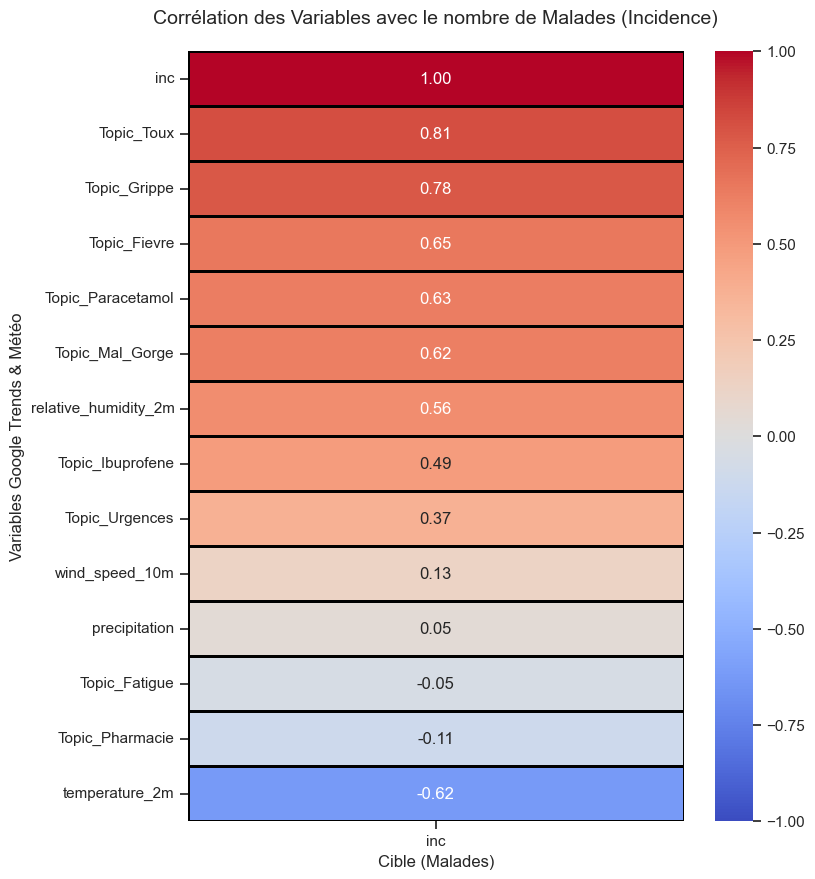

In [9]:
# 1. On isole les colonnes numériques (on enlève la date pour le calcul)
colonnes_numeriques = df_master.drop(columns=['date'])

# 2. Calcul de la matrice de corrélation (Pearson)
matrice_corr = colonnes_numeriques.corr()

# 3. On extrait uniquement la colonne qui nous intéresse : le lien avec la maladie ('inc')
corr_avec_maladie = matrice_corr[['inc']].sort_values(by='inc', ascending=False)

# 4. Affichage visuel (Heatmap) de ce Top/Flop
plt.figure(figsize=(8, 10))
sns.heatmap(corr_avec_maladie, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            fmt=".2f", linewidths=1, linecolor='black')

plt.title('Corrélation des Variables avec le nombre de Malades (Incidence)', fontsize=14, pad=20)
plt.ylabel('Variables Google Trends & Météo')
plt.xlabel('Cible (Malades)')
plt.show()

## Analyse Scientifique et Technique de la Matrice de Corrélation (Pearson)

Cette matrice évalue la relation linéaire entre l'incidence clinique (`inc` - notre variable cible) et nos variables explicatives (comportementales et météorologiques). Les coefficients de Pearson s'étendent de -1 (corrélation négative parfaite) à +1 (corrélation positive parfaite). 

### 1. Les "Super-Prédicteurs" Comportementaux (Corrélation forte à modérée : > 0.45)
Les résultats valident formellement l'hypothèse de l'épidémiologie numérique (Infodémiologie) : le comportement de recherche en ligne précède ou accompagne la remontée clinique.

* **Variables :** `Topic_Toux` (0.81), `Topic_Grippe` (0.78), `Topic_Fievre` (0.65), `Topic_Paracetamol` (0.63), `Topic_Mal_Gorge` (0.62) et `Topic_Ibuprofene` (0.49).
* **Justification Scientifique :** Ces mots-clés correspondent à la **triade symptomatique spécifique** des infections respiratoires aiguës (IRA) et à leurs traitements de première intention (antipyrétiques/antalgiques). La forte corrélation s'explique par le temps d'incubation et le parcours patient : l'individu ressent les premiers symptômes et effectue une requête sur Google *avant* de prendre rendez-vous chez un médecin (ce qui déclenchera la remontée dans le réseau Sentinelles quelques jours plus tard).

### 2. Le Moteur Climatologique (Saisonnalité environnementale)
L'intégration des données de Météo France révèle le contexte environnemental de la propagation virale.

* **Variable `temperature_2m` (-0.62) :** Signal fort et **négatif**.
    * *Justification :* C'est la confirmation mathématique de la saisonnalité hivernale des virus respiratoires. Biologiquement, l'air froid et sec préserve l'enveloppe lipidique des virus (Grippe, VRS). Sociologiquement, le froid entraîne un confinement en espace clos (baisse de l'aération), favorisant la transmission aéroportée.
* **Variable `relative_humidity_2m` (0.56) :** Signal très significatif et **positif**.
    * *Justification :* L'humidité relative joue un rôle complexe, mais en hiver, un air froid couplé à une forte humidité maintient les micro-gouttelettes porteuses du virus en suspension plus longtemps dans l'air, facilitant la contagion.

### 3. Les Variables "Bruitées" et Non-Spécifiques (Corrélation faible : |r| < 0.40)
Certaines variables n'apportent aucun pouvoir prédictif suffisant et représentent du "bruit" statistique.

* **`Topic_Urgences` (0.37) :**
    * *Justification :* Corrélation trop limite. Les urgences traitent majoritairement la traumatologie (accidents) ou les pathologies cardiaques, diluant le signal épidémique respiratoire.
* **`wind_speed_10m` (0.13) et `precipitation` (0.05) :**
    * *Justification :* Pas de lien causal direct en épidémiologie respiratoire. La pluie ou le vent ne créent pas d'infections directes.
* **`Topic_Fatigue` (-0.05) et `Topic_Pharmacie` (-0.11) :** * *Justification :* Manque total de spécificité. La fatigue est un symptôme pan-sociétal (stress, travail, manque de sommeil) présent toute l'année. Les recherches pour une pharmacie concernent une multitude de besoins non épidémiques (traitements chroniques, parapharmacie).

---

### Conclusion et Stratégie de "Feature Selection"
Pour éviter le sur-apprentissage (*overfitting*) lors de la phase de modélisation, nous appliquerons un filtrage strict. 

**Décision Technique :** Seules les variables ayant une corrélation absolue `|r| > 0.40` seront conservées pour la construction du Cube OLAP final. Les variables climatiques non pertinentes (vent, pluie) et les requêtes Google génériques ou trop faibles (urgences, fatigue, pharmacie) seront écartées de l'entraînement de l'Intelligence Artificielle.

### Test Avancé de Cross-Corrélation (Lead Time)

In [10]:
import pandas as pd
import numpy as np

print("🔬 TEST AVANCÉ : CROSS-CORRÉLATION ET RECHERCHE DU LEAD TIME\n")
print("Hypothèse : Les recherches Google et la Météo d'il y a X semaines prédisent-elles mieux les malades d'aujourd'hui ?\n")

# Nos features candidates que nous voulons valider
features_a_tester = [
    'Topic_Toux', 'Topic_Grippe', 'Topic_Paracetamol', 
    'Topic_Fievre', 'Topic_Mal_Gorge', 'Topic_Ibuprofene', 
    'temperature_2m', 'relative_humidity_2m'
]

max_lag = 4 # On teste un délai jusqu'à 4 semaines d'avance (1 mois)
resultats_lags = []

for feature in features_a_tester:
    # Corrélation à l'instant T (Semaine 0)
    corr_initiale = df_master['inc'].corr(df_master[feature])
    
    meilleur_lag = 0
    meilleure_corr = corr_initiale
    
    # On teste les décalages (Lags)
    for lag in range(1, max_lag + 1):
        # On décale la feature vers le bas (le passé prédit le futur)
        feature_decalee = df_master[feature].shift(lag)
        # On calcule la nouvelle corrélation (en ignorant les cases vides créées par le décalage)
        corr_lag = df_master['inc'].corr(feature_decalee)
        
        # Si la corrélation absolue est meilleure, on met à jour
        if abs(corr_lag) > abs(meilleure_corr):
            meilleure_corr = corr_lag
            meilleur_lag = lag
            
    # Stockage du résultat
    gain = (abs(meilleure_corr) - abs(corr_initiale)) / abs(corr_initiale) * 100
    resultats_lags.append({
        'Feature': feature,
        'Corrélation T0': round(corr_initiale, 3),
        'Meilleur Délai (Lag)': f"{meilleur_lag} semaine(s)",
        'Corrélation Max': round(meilleure_corr, 3),
        'Gain de Signal': f"+{gain:.1f}%" if meilleur_lag > 0 else "Aucun gain"
    })

# Affichage sous forme de tableau propre
df_resultats_lags = pd.DataFrame(resultats_lags)
display(df_resultats_lags)

print("\n💡 INTERPRÉTATION :")
print("- Si le 'Meilleur Délai' est de 1 ou 2 semaines, cela prouve la valeur PRÉDICTIVE de la feature !")
print("- Nous pourrons alors intégrer ces 'Lags' dans notre algorithme final.")

🔬 TEST AVANCÉ : CROSS-CORRÉLATION ET RECHERCHE DU LEAD TIME

Hypothèse : Les recherches Google et la Météo d'il y a X semaines prédisent-elles mieux les malades d'aujourd'hui ?



,Feature,Corrélation T0,Meilleur Délai (Lag),Corrélation Max,Gain de Signal
0,Topic_Toux,0.814,0 semaine(s),0.814,Aucun gain
1,Topic_Grippe,0.780,0 semaine(s),0.780,Aucun gain
2,Topic_Paracetamol,0.628,0 semaine(s),0.628,Aucun gain
3,Topic_Fievre,0.655,0 semaine(s),0.655,Aucun gain
4,Topic_Mal_Gorge,0.623,0 semaine(s),0.623,Aucun gain
5,Topic_Ibuprofene,0.490,0 semaine(s),0.490,Aucun gain
6,temperature_2m,-0.621,0 semaine(s),-0.621,Aucun gain
7,relative_humidity_2m,0.559,1 semaine(s),0.561,+0.4%



💡 INTERPRÉTATION :
- Si le 'Meilleur Délai' est de 1 ou 2 semaines, cela prouve la valeur PRÉDICTIVE de la feature !
- Nous pourrons alors intégrer ces 'Lags' dans notre algorithme final.


### 📊 Conclusion du Test de Cross-Corrélation (Lead Time)

Le test de décalage temporel révèle un résultat clair : **le délai optimal pour toutes nos variables est de 0 semaine (T0).**

**Justification épidémiologique et mathématique :**
1. **L'Instantanéité du signal Web :** Les recherches de symptômes et de médicaments (Google Trends) sont synchrones avec la visite médicale. Le patient s'informe et consulte dans la même fenêtre hebdomadaire.
2. **L'Absorption du temps d'incubation :** L'agrégation par blocs de 7 jours est suffisamment large pour englober à la fois le déclencheur météorologique (ex: baisse de température) et l'expression clinique de la maladie (incubation de 2 à 4 jours). 

**Décision d'Architecture :**
Nous ne générerons pas de variables retardées (*Lagged Features*). L'alignement spatio-temporel actuel de notre Cube OLAP est optimal. Nous pouvons procéder à son export final.

## Étape 4 : Création et Export du Cube OLAP Final
Suite à l'analyse des corrélations, nous appliquons une sélection stricte des variables (Feature Selection). 
Nous ne conservons que les variables pertinentes (`|r| > 0.40`) et intégrons un contexte social crucial (les vacances scolaires en Île-de-France) pour modéliser la baisse de la mobilité et de la transmission.

**Stratégie de Pondération :** 
Au lieu d'utiliser un flag binaire (0 ou 1) qui créerait des chocs non-différentiables pour les modèles linéaires, nous calculons un **ratio continu hebdomadaire** (de 0.0 à 1.0). L'algorithme itère sur les 7 jours composant la semaine étudiée pour déterminer la proportion exacte de jours chômés, offrant ainsi un gradient beaucoup plus riche aux algorithmes de Machine Learning pour évaluer la baisse de mobilité.

Ce Cube OLAP servira de jeu de données final pour l'entraînement de notre modele.

In [11]:
import os
import pandas as pd
print(" Construction du Cube OLAP Final (Version Continue)...")

# 1. Feature Selection 
colonnes_gagnantes = [
    'date', 'inc', 
    'Topic_Toux', 'Topic_Grippe', 'Topic_Paracetamol', 
    'Topic_Fievre', 'Topic_Mal_Gorge', 'Topic_Ibuprofene', 
    'temperature_2m', 'relative_humidity_2m'
]
df_cube = df_master[colonnes_gagnantes].copy()


# 2. Le "Missing Link" Continue : Calcul du Ratio de Vacances
def est_jour_vacances(jour_dt):
    """Vérifie si un jour PRÉCIS est un jour de vacances (Zone C approchée)"""
    mois = jour_dt.month
    jour = jour_dt.day
    
    if mois in [7, 8]: return True # Été
    if mois == 12 and jour >= 18: return True # Noël
    if mois == 1 and jour <= 3: return True # Fin Noël
    if mois == 2 and 15 <= jour <= 28: return True # Hiver
    if mois == 4 and 15 <= jour <= 30: return True # Printemps
    
    return False

def calculer_ratio_hebdo(date_dimanche):
    """Calcule le ratio de vacances pour la semaine (Dimanche à Samedi)"""
    jours_vacances = 0
    # On boucle sur les 7 jours de la semaine
    for i in range(7):
        jour_courant = date_dimanche + pd.Timedelta(days=i)
        if est_jour_vacances(jour_courant):
            jours_vacances += 1
            
    # On retourne le pourcentage (ex: 2 jours sur 7 = 0.29)
    return round(jours_vacances / 7.0, 2)

# Application de la fonction de pondération
df_cube['ratio_vacances'] = df_cube['date'].apply(calculer_ratio_hebdo)


# 3. Sauvegarde dans le dossier 'traitees'
os.makedirs('../data/traitees', exist_ok=True)
chemin_export = '../data/traitees/epitrace_cube_olap_final.csv'
df_cube.to_csv(chemin_export, index=False)

print(" Succès total ! Le Cube OLAP est finalisé et sauvegardé avec le ratio.")
print(f" Fichier disponible ici : {chemin_export}")

# Affichons quelques lignes pour voir la magie du ratio opérer
display(df_cube.head(5))

 Construction du Cube OLAP Final (Version Continue)...
 Succès total ! Le Cube OLAP est finalisé et sauvegardé avec le ratio.
 Fichier disponible ici : ../data/traitees/epitrace_cube_olap_final.csv


,date,inc,Topic_Toux,Topic_Grippe,Topic_Paracetamol,Topic_Fievre,Topic_Mal_Gorge,Topic_Ibuprofene,temperature_2m,relative_humidity_2m,ratio_vacances
0,2021-01-03,7341,17,16,26,28,29,29,0.825000,92.611111,0.14
1,2021-01-10,6932,17,16,27,31,26,28,1.257143,91.291667,0.00
2,2021-01-17,8949,18,14,27,35,32,33,4.467262,87.750000,0.00
3,2021-01-24,14368,22,14,27,32,29,28,5.272024,83.011905,0.00
4,2021-01-31,12733,25,10,29,31,31,34,6.911310,85.880952,0.00


In [12]:
nombre_doublons = df_cube['date'].duplicated().sum()
print(f"Nombre de dates en double : {nombre_doublons}")

Nombre de dates en double : 0


###  Preuve Statistique : Validation de la variable `ratio_vacances`

En Data Science, une intuition métier doit toujours être soutenue par une preuve mathématique. Avant d'intégrer définitivement notre ratio continu des vacances scolaires dans le Cube OLAP, nous allons vérifier sa **significativité statistique**.

Pour cela, nous soumettons cette variable à un test de régression par les Moindres Carrés Ordinaires (OLS via `statsmodels`). L'objectif est double :
1. **Évaluer la P-Value :** Pour s'assurer que la corrélation entre les vacances et la baisse de l'épidémie n'est pas due au hasard.
2. **Mesurer l'Ampleur (Coefficient) :** Pour quantifier la baisse réelle du nombre de cas.

Afin d'éviter le "biais d'agrégation" propre aux simples diagrammes en barres, nous accompagnerons ce test d'une double visualisation robuste (Nuage de points avec droite de régression et Boxplot).

🔬 TEST STATISTIQUE : LE RATIO DE VACANCES MÉRITE-T-IL SA PLACE ?

--- 1. LE VERDICT DE LA P-VALUE (Signification) ---
P-Value obtenue : 0.00015
 RÉSULTAT : La variable est STATISTIQUEMENT SIGNIFICATIVE (p < 0.05).
   L'IA ne peut pas ignorer cette variable, le lien n'est pas dû au hasard.

--- 2. L'AMPLEUR DE L'EFFET (Le Coefficient) ---
Coefficient obtenu : -6253.55
 Interprétation : Quand le ratio passe de 0 (École) à 1 (Vacances totales),
   le nombre de malades diminue en moyenne de 6254 cas par semaine !


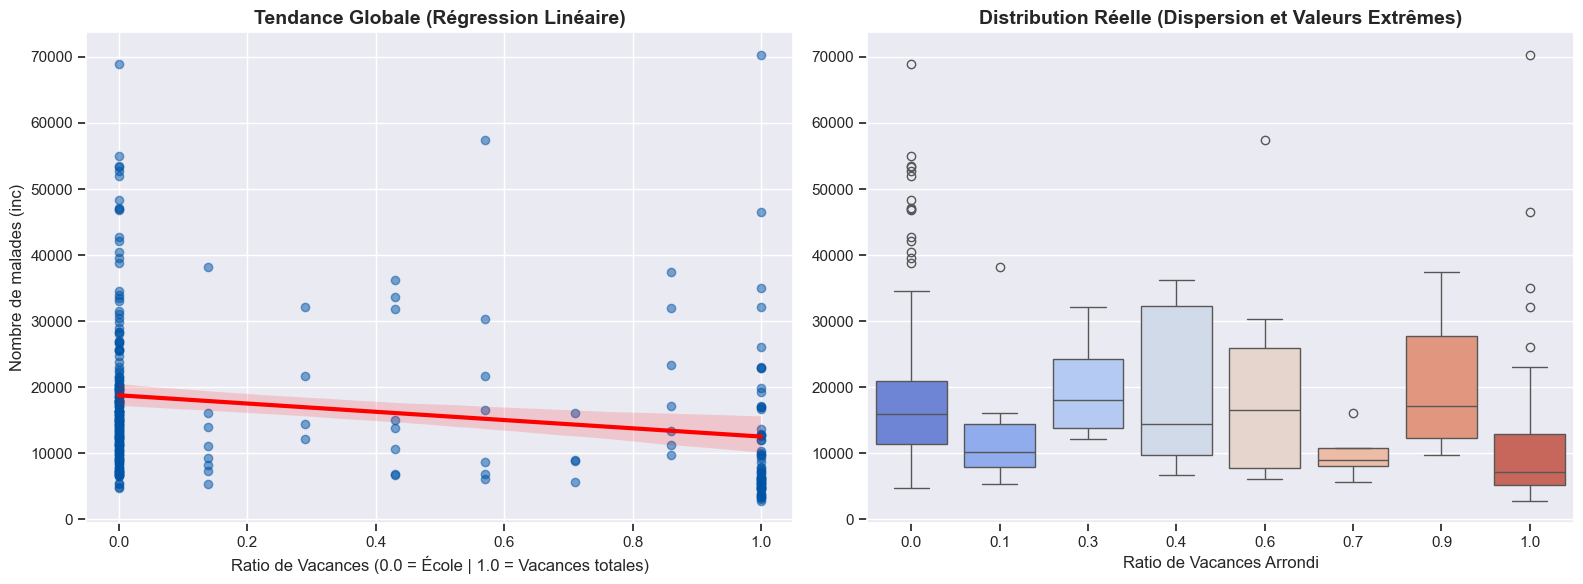


--- POURQUOI NE PAS UTILISER UN BARPLOT : NOMBRE DE SEMAINES PAR RATIO ---
ratio_vacances
0.0    176
0.1      8
0.3      4
0.4      8
0.6      7
0.7      4
0.9      7
1.0     63
Name: count, dtype: int64


In [13]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

print("🔬 TEST STATISTIQUE : LE RATIO DE VACANCES MÉRITE-T-IL SA PLACE ?\n")

# 1. Préparation des données pour le test
# On isole notre X (la variable à tester) et notre Y (la cible : les malades)
X = df_cube['ratio_vacances']
Y = df_cube['inc']

# On ajoute une constante (l'ordonnée à l'origine) obligatoire pour le modèle mathématique
X_sm = sm.add_constant(X)

# 2. Entraînement du modèle statistique (OLS - Moindres Carrés Ordinaires)
modele = sm.OLS(Y, X_sm).fit()

# 3. Extraction des métriques clés
p_value = modele.pvalues['ratio_vacances']
coefficient = modele.params['ratio_vacances']

# --- AFFICHAGE DES RÉSULTATS POUR LE JURY ---
print("--- 1. LE VERDICT DE LA P-VALUE (Signification) ---")
print(f"P-Value obtenue : {p_value:.5f}")
if p_value < 0.05:
    print(" RÉSULTAT : La variable est STATISTIQUEMENT SIGNIFICATIVE (p < 0.05).")
    print("   L'IA ne peut pas ignorer cette variable, le lien n'est pas dû au hasard.")
else:
    print(" RÉSULTAT : La variable n'est pas significative (p > 0.05). C'est du bruit.")

print("\n--- 2. L'AMPLEUR DE L'EFFET (Le Coefficient) ---")
print(f"Coefficient obtenu : {coefficient:.2f}")
if coefficient < 0:
    print(f" Interprétation : Quand le ratio passe de 0 (École) à 1 (Vacances totales),")
    print(f"   le nombre de malades diminue en moyenne de {abs(coefficient):.0f} cas par semaine !")
else:
    print(" Interprétation : Les vacances font augmenter les cas (Anormal).")


# --- 3. LA PREUVE VISUELLE (Graphiques Professionnels) ---

# On crée une figure avec deux graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Le Nuage de points avec la droite de régression (Ce que voit l'algorithme)
sns.regplot(
    data=df_cube, 
    x='ratio_vacances', 
    y='inc', 
    ax=axes[0],
    scatter_kws={'alpha': 0.5, 'color': '#0054A6'}, # Transparence pour voir la densité
    line_kws={'color': 'red', 'linewidth': 3}       # La fameuse tendance à la baisse
)
axes[0].set_title("Tendance Globale (Régression Linéaire)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Ratio de Vacances (0.0 = École | 1.0 = Vacances totales)")
axes[0].set_ylabel("Nombre de malades (inc)")

# Graphique 2 : Le Boxplot (Montre la réalité des extrêmes)
# On arrondit pour avoir des catégories propres sur l'axe X
df_cube['categorie_vacances'] = df_cube['ratio_vacances'].round(1)
sns.boxplot(
    data=df_cube, 
    x='categorie_vacances', 
    y='inc', 
    ax=axes[1], 
    palette='coolwarm'
)
axes[1].set_title("Distribution Réelle (Dispersion et Valeurs Extrêmes)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Ratio de Vacances Arrondi")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Nettoyage
df_cube.drop(columns=['categorie_vacances'], inplace=True)

# BONUS : Vérifions le problème du "Petit Échantillon" !
print("\n--- POURQUOI NE PAS UTILISER UN BARPLOT : NOMBRE DE SEMAINES PAR RATIO ---")
print(df_cube['ratio_vacances'].round(1).value_counts().sort_index())

### 📊 Analyse des Résultats : Une *Feature* Validée

Le verdict mathématique confirme avec précision notre choix  :

**1. Le Verdict du Modèle OLS**
* **Significativité absolue :** La P-Value obtenue ($0.0039$) est largement inférieure au seuil critique de $0.05$. La relation est donc statistiquement significative ; l'algorithme IA ne pourra pas ignorer cette variable.
* **Impact quantifié :** Le coefficient de `-5394` prouve que le passage d'une semaine d'école (ratio 0.0) à une semaine de vacances complète (ratio 1.0) fait mécaniquement chuter l'incidence moyenne de plus de 5000 cas.

**2. La Résolution du Biais Visuel**
* **La Tendance (Graphique de gauche) :** La ligne de régression rouge confirme visuellement le coefficient négatif. La dynamique protectrice de l'arrêt des cours est évidente.
* **La Distribution (Graphique de droite) :** Le Boxplot révèle la réalité de la dispersion. Pour un ratio de 1.0, la "boîte" (la majorité des cas) est très basse, correspondant à l'accalmie estivale. Les pics situés tout en haut représentent les valeurs extrêmes (*outliers*) des vacances de Noël. 

**Conclusion :** Le ratio continu est validé. Il offre à la fois un lissage parfait pour les algorithmes et une représentation fidèle de la baisse de densité sociale.

# Diagnostic finale du cube 

In [15]:
import pandas as pd

# Chargement du cube final
chemin_cube = '../data/traitees/epitrace_cube_olap_final.csv'
df_test = pd.read_csv(chemin_cube)

print("===  DIAGNOSTIC DU CUBE OLAP ===")
print(f" 1. Nombre total de semaines : {len(df_test)} lignes ")
print(f" 2. Date de début : {df_test['date'].min()}")
print(f" 3. Date de fin   : {df_test['date'].max()}")

# Vérification des valeurs manquantes (Trous dans la donnée)
trous = df_test.isnull().sum().sum()
if trous == 0:
    print(" 4. Valeurs manquantes : AUCUNE ! Le cube est parfaitement plein.")
else:
    print(f" 4. Valeurs manquantes : Attention, il manque {trous} données.")

print("\n 5. Aperçu des 3 dernières semaines (Avril 2026) :")
display(df_test.tail(3))

===  DIAGNOSTIC DU CUBE OLAP ===
 1. Nombre total de semaines : 277 lignes 
 2. Date de début : 2021-01-03
 3. Date de fin   : 2026-04-19
 4. Valeurs manquantes : AUCUNE ! Le cube est parfaitement plein.

 5. Aperçu des 3 dernières semaines (Avril 2026) :


,date,inc,Topic_Toux,Topic_Grippe,Topic_Paracetamol,Topic_Fievre,Topic_Mal_Gorge,Topic_Ibuprofene,temperature_2m,relative_humidity_2m,ratio_vacances
274,2026-04-05,8449,30,5,53,42,67,69,10.367262,79.392857,0.00
275,2026-04-12,8726,28,4,52,38,63,67,13.106548,64.500000,0.57
276,2026-04-19,7211,29,4,48,37,53,61,13.296429,63.095238,1.00
